# Project 1: Advanced EDA & Feature Engineering

## Setup & Initial Exploration
### Importing Libraries

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.impute import KNNImputer

### Loading Dataset

In [2]:
df = pd.read_csv("retail_store_sales.csv")

In [3]:
df.shape

(12575, 11)

In [4]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


### Initial Statistical Summary

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


In [6]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

## Phase 1: Handling Missing Data

### Discount Applied Exploring & Filling Missing Values

In [7]:
df["Discount Applied"].value_counts(dropna = False)

Discount Applied
True     4219
NaN      4199
False    4157
Name: count, dtype: int64

In [8]:
df["Discount Applied"] = df["Discount Applied"].fillna("Unknown")

In [9]:
df["Discount Applied"].value_counts(dropna = False)

Discount Applied
True       4219
Unknown    4199
False      4157
Name: count, dtype: int64

### Investigating Price Per Unit, Quantity & Total Spent Relationship

In [10]:
df[df["Total Spent"].isnull() & df["Price Per Unit"].notnull() & df["Quantity"].notnull()].shape[0]

0

In [11]:
df[df["Price Per Unit"].isnull() & df["Total Spent"].notnull() & df["Quantity"].notnull()].shape[0]

609

In [12]:
df[df["Quantity"].isnull() & df["Total Spent"].notnull() & df["Price Per Unit"].notnull()].shape[0]

0

In [13]:
df[df["Quantity"].isnull() & df["Total Spent"].isnull() & df["Price Per Unit"].notnull()].shape[0]

604

### Price Per Unit Formula Recovery

In [14]:
df.loc[df["Price Per Unit"].isnull(), "Price Per Unit"] = df["Total Spent"]/df["Quantity"]

In [15]:
df[df["Price Per Unit"].isnull() & df["Total Spent"].notnull() & df["Quantity"].notnull()].shape[0]

0

### Checking Distribution Total Spent & Quantity (for Median Imputation Strategy)

<Axes: >

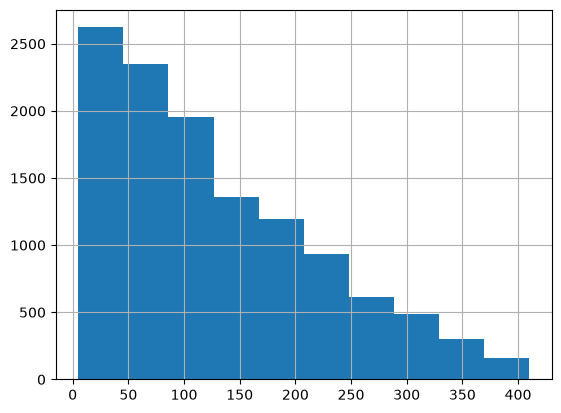

In [16]:
df["Total Spent"].hist()

<Axes: >

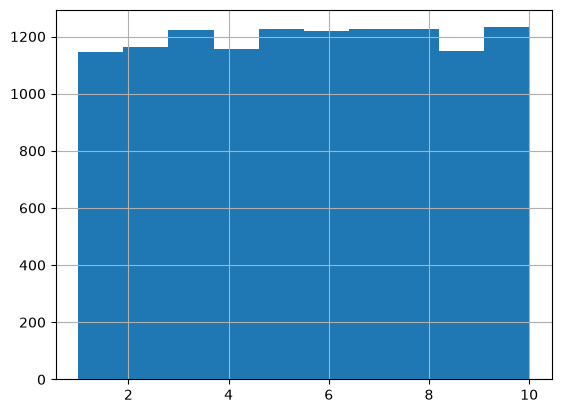

In [17]:
df["Quantity"].hist()

### Quantity & Total Spent Median Imputation

In [18]:
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df["Total Spent"] = df["Total Spent"].fillna(df["Total Spent"].median())

In [19]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit         0
Quantity               0
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied       0
dtype: int64

In [65]:
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Transaction Month,Transaction Day of Week,Discount Encoded
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,4,Monday,1
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,7,Sunday,1
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,10,Wednesday,0
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,Unknown,5,Saturday,-1
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,10,Sunday,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,Unknown,9,Sunday,-1
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False,8,Friday,0
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,Unknown,8,Saturday,-1
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True,12,Saturday,1


### Item Category-Price Lookup Mapping

In [21]:
df.groupby(['Category', 'Price Per Unit'])['Item'].nunique().sort_values(ascending=False).head(10)

Category   Price Per Unit
Beverages  5.0               1
           6.5               1
           8.0               1
           9.5               1
           11.0              1
           12.5              1
           14.0              1
           15.5              1
           17.0              1
           18.5              1
Name: Item, dtype: int64

In [22]:
item_lookup = df[df['Item'].notnull()][["Category", "Price Per Unit", "Item"]].drop_duplicates(subset = ["Category", "Price Per Unit"])

In [23]:
item_lookup

,Category,Price Per Unit,Item
0,Patisserie,18.5,Item_10_PAT
1,Milk Products,29.0,Item_17_MILK
2,Butchers,21.5,Item_12_BUT
3,Beverages,27.5,Item_16_BEV
4,Food,12.5,Item_6_FOOD
...,...,...,...
1953,Food,27.5,Item_16_FOOD
2031,Food,32.0,Item_19_FOOD
2044,Electric household essentials,24.5,Item_14_EHE
2590,Electric household essentials,8.0,Item_3_EHE


In [24]:
item_lookup.shape

(200, 3)

In [25]:
item_lookup["key"] = item_lookup["Category"].astype(str) + "_" + item_lookup["Price Per Unit"].astype(str)

In [26]:
item_lookup.head(10)

,Category,Price Per Unit,Item,key
0,Patisserie,18.5,Item_10_PAT,Patisserie_18.5
1,Milk Products,29.0,Item_17_MILK,Milk Products_29.0
2,Butchers,21.5,Item_12_BUT,Butchers_21.5
3,Beverages,27.5,Item_16_BEV,Beverages_27.5
4,Food,12.5,Item_6_FOOD,Food_12.5
6,Food,5.0,Item_1_FOOD,Food_5.0
8,Furniture,27.5,Item_16_FUR,Furniture_27.5
9,Butchers,36.5,Item_22_BUT,Butchers_36.5
10,Butchers,8.0,Item_3_BUT,Butchers_8.0
12,Food,6.5,Item_2_FOOD,Food_6.5


In [27]:
df.shape

(12575, 11)

In [28]:
df['key'] = df['Category'].astype(str) + "_" + df['Price Per Unit'].astype(str)

In [29]:
df.shape

(12575, 12)

In [30]:
df.head(5)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,key
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,Patisserie_18.5
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,Milk Products_29.0
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,Butchers_21.5
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,Unknown,Beverages_27.5
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,Food_12.5


In [31]:
item_map = item_lookup.set_index("key")["Item"]

In [32]:
item_map

key
Patisserie_18.5                        Item_10_PAT
Milk Products_29.0                    Item_17_MILK
Butchers_21.5                          Item_12_BUT
Beverages_27.5                         Item_16_BEV
Food_12.5                              Item_6_FOOD
                                          ...     
Food_27.5                             Item_16_FOOD
Food_32.0                             Item_19_FOOD
Electric household essentials_24.5     Item_14_EHE
Electric household essentials_8.0       Item_3_EHE
Butchers_17.0                           Item_9_BUT
Name: Item, Length: 200, dtype: str

In [33]:
df.loc[df['Item'].isnull(), 'Item'] = df.loc[df['Item'].isnull(), 'key'].map(item_map)

In [34]:
df['Item'].isnull().sum()

np.int64(0)

In [35]:
df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
key                 0
dtype: int64

In [36]:
df = df.drop(columns=['key'])

In [37]:
df.shape

(12575, 11)

## Phase 2: Outlier Detection & Treatment (IQR Method)

### Total Spent IQR Outlier Checking and Capping

In [38]:
Q1 = df["Total Spent"].quantile(0.25)
Q3 = df["Total Spent"].quantile(0.75)

print(Q1)
print(Q3)

55.0
184.0


In [39]:
IQR = Q3 - Q1
print(IQR)

129.0


In [40]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)

-138.5
377.5


In [41]:
df[df["Total Spent"] > upper_bound]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
27,TXN_1599706,CUST_14,Furniture,Item_25_FUR,41.0,10.0,410.0,Credit Card,In-store,2024-03-24,True
120,TXN_8215469,CUST_17,Milk Products,Item_23_MILK,38.0,10.0,380.0,Digital Wallet,In-store,2024-03-16,Unknown
129,TXN_1112365,CUST_19,Food,Item_24_FOOD,39.5,10.0,395.0,Cash,Online,2023-09-24,Unknown
133,TXN_2953434,CUST_25,Furniture,Item_25_FUR,41.0,10.0,410.0,Credit Card,In-store,2023-08-10,Unknown
135,TXN_1249742,CUST_05,Milk Products,Item_24_MILK,39.5,10.0,395.0,Digital Wallet,Online,2024-03-21,Unknown
...,...,...,...,...,...,...,...,...,...,...,...
12209,TXN_1113295,CUST_11,Milk Products,Item_25_MILK,41.0,10.0,410.0,Digital Wallet,Online,2022-08-23,False
12216,TXN_9897293,CUST_23,Patisserie,Item_24_PAT,39.5,10.0,395.0,Cash,Online,2023-05-26,True
12243,TXN_8227894,CUST_24,Furniture,Item_23_FUR,38.0,10.0,380.0,Credit Card,In-store,2022-07-02,Unknown
12542,TXN_7484072,CUST_02,Butchers,Item_25_BUT,41.0,10.0,410.0,Credit Card,In-store,2024-12-31,False


### Total Spent IQR Outlier Capping

In [42]:
df['Total Spent'] = df['Total Spent'].clip(lower=lower_bound, upper=upper_bound)

In [43]:
df[df['Total Spent'] > upper_bound].shape[0]

0

### Quantity IQR Outlier Check

In [44]:
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)

print(Q1)
print(Q3)

3.0
8.0


In [46]:
IQR = Q3 - Q1
print("IQR:", IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

IQR: 5.0
Lower Bound: -4.5
Upper Bound: 15.5


In [47]:
df[df['Quantity'] > upper_bound].shape[0]

0

### No Outliers Found in Quantity

### Price Per Unit IQR Outlier Checking

In [48]:
Q1 = df["Price Per Unit"].quantile(0.25)
Q3 = df["Price Per Unit"].quantile(0.75)

print(Q1)
print(Q3)

14.0
33.5


In [49]:
IQR = Q3 - Q1
print("IQR:", IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

IQR: 19.5
Lower Bound: -15.25
Upper Bound: 62.75


In [51]:
df[df['Price Per Unit'] > upper_bound].shape[0]

0

## Phase 3: Feature Engineering

### Converting Transaction Date to Datetime

In [52]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  str           
 1   Customer ID       12575 non-null  str           
 2   Category          12575 non-null  str           
 3   Item              12575 non-null  str           
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          12575 non-null  float64       
 6   Total Spent       12575 non-null  float64       
 7   Payment Method    12575 non-null  str           
 8   Location          12575 non-null  str           
 9   Transaction Date  12575 non-null  datetime64[us]
 10  Discount Applied  12575 non-null  object        
dtypes: datetime64[us](1), float64(3), object(1), str(6)
memory usage: 1.1+ MB


### Creating Transaction Month Feature

In [53]:
df['Transaction Month'] = df['Transaction Date'].dt.month
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Transaction Month
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,4
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,7
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,10
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,Unknown,5
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,10


### Creating Transaction Day of Week Feature

In [55]:
df['Transaction Day of Week'] = df['Transaction Date'].dt.day_name()
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Transaction Month,Transaction Day of Week
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,4,Monday
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,7,Sunday
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,10,Wednesday
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,Unknown,5,Saturday
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,10,Sunday


### Analyzing Discount Applied vs Total Spent (EDA Insight)

In [60]:
df.groupby('Discount Applied')['Total Spent'].mean()

Discount Applied
False      128.754029
True       129.212728
Unknown    127.279948
Name: Total Spent, dtype: float64

### Creating Discount Encoded Feature

In [63]:
df['Discount Encoded'] = df['Discount Applied'].map({True: 1, False: 0, 'Unknown': -1})

In [64]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Transaction Month,Transaction Day of Week,Discount Encoded
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,4,Monday,1
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,7,Sunday,1
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,10,Wednesday,0
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,Unknown,5,Saturday,-1
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,10,Sunday,0
